<a href="https://colab.research.google.com/github/CHINGUYEN-alt/Yolov8-detecton-result/blob/main/Yolov8_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pickle
import sys
import os
import pandas as pd
import numpy as np
from google.colab import drive
from os.path import join
import warnings
warnings.filterwarnings("ignore")

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. link to file
file_path = "/content/drive/My Drive/library/lib/LSWMD.pkl"

# read data from file pickle
with open(file_path, 'rb') as file:
   data = pd.read_pickle(file_path)

# save data from CSV to read faster
data.to_csv('/content/drive/My Drive/library/lib/LSWMD.csv', index=False)


# Mục mới

In [2]:
# Kiểm tra kiểu dữ liệu của file pickle
print(type(data))
print(data.keys())
print(data.head())
print(data.info())

NameError: name 'data' is not defined

In [ ]:
print(data.tail())

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os
from tqdm import tqdm

# save images
save_dir = "/content/imagestrain"
os.makedirs(save_dir, exist_ok=True)

# Load data from WM-811K
data = pd.read_pickle("/content/drive/My Drive/library/lib/LSWMD.pkl")

for i, wafer in tqdm(enumerate(data["waferMap"]), total=len(data)):
    if wafer is not None:
        # change images to gray 0-255
        wafer_gray = np.uint8(wafer * 255)

        # Resize  640x640
        wafer_resized = cv2.resize(wafer_gray, (640,640), interpolation=cv2.INTER_NEAREST)


        # trans gray to RGB 3 channels
        wafer_rgb = cv2.cvtColor(wafer_resized, cv2.COLOR_GRAY2RGB)

        # save link
        save_path = os.path.join(save_dir, f"wafer_{i}.jpg")

        # save
        cv2.imwrite(save_path, wafer_rgb)


In [ ]:
##Automatically classify and copy wafer images to subfolders corresponding to the defect label

import os
import shutil
from pathlib import Path
import pandas as pd

# Load data
data = pd.read_pickle("/content/drive/My Drive/library/lib/LSWMD.pkl")

# check datta
if "failureType" not in data.columns or "waferMap" not in data.columns:
 print("The data does not contain the column 'failureType' or 'waferMap'. Please check the data again.")
 exit()
source_dir = Path("/content/imagestrain")

# file have images had classify
target_dir = Path("/content/drive/MyDrive/datasheet/images/Train")
target_dir.mkdir(parents=True, exist_ok=True)

# created file label
classes = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Random", "Scratch", "Near-full"]
for cls in classes:
    os.makedirs(target_dir / cls, exist_ok=True)
os.makedirs(target_dir / "None", exist_ok=True)

# count "None"
none_count = 0
max_none = 7000


for i, label in enumerate(data["failureType"]):
    img_name = f"wafer_{i}.jpg"
    src_path = source_dir / img_name

    if not src_path.exists():
        print(f" not found {img_name}")
        continue

    # take labels
    if isinstance(label, list):
        label_str = str(label[0]).strip("[]'") if label else "None"
    else:
        label_str = str(label).strip("[]'")

    # If the label is invalid, assign "None"
    if label_str not in classes:
        label_str = "None"

    # Limit unlabeled images
    if label_str == "None":
        if none_count >= max_none:
            continue
        none_count += 1

   # Move photos
    dest_path = target_dir / label_str / img_name
    shutil.copy(str(src_path), str(dest_path))

print(f"✅ Copied {img_name} to folder {label_str}")

print(f"\n✅ Classification complete. Saved {none_count} unlabeled images.")


tạo ảnh màu

In [ ]:
# Enhance and colorize grayscale images for each defects
import os
import cv2
from pathlib import Path
from tqdm import tqdm

# file have  grayscale images
input_dir = Path("/content/drive/MyDrive/datasheet/images/train/Center")  # input

output_dir = Path("/content/drive/MyDrive/datasheet/images/train/Center")  # out put
output_dir.mkdir(parents=True, exist_ok=True)

image_files = [f for f in os.listdir(input_dir) if f.endswith('.jpg')]
print(f"Total number of images to process: {len(image_files)}")

# Tạo CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

for img_name in tqdm(image_files, desc="images coloring"):
    img_path = input_dir / img_name

    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"can't read iamges {img_name}")
        continue

    # CLAHE
    enhanced = clahe.apply(gray)

    # colorringb by colormap
    colored = cv2.applyColorMap(enhanced, cv2.COLORMAP_TURBO)

    # Lưu ảnh
    cv2.imwrite(str(output_dir / img_name), colored)

print(f"Finish coloring and save the image {output_dir}")


In [ ]:
!pip install ultralytics --no-cache-dir --no-binary :all:
# cài ultra;ytics


In [3]:
from google.colab import drive
drive.mount('/content/drive')
# mount drive
!git clone https://github.com/CHINGUYEN-alt/Yolov8-detecton-result.git

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'Yolov8-detecton-result' already exists and is not an empty directory.


đếm ảnh trong thư mục

In [ ]:
# check version of computer
import torch
import torchvision
import cv2
import platform
import os
import psutil
import subprocess
import ultralytics

print("🔍 System Information:")
print("OS:", platform.platform())
print("Python version:", platform.python_version())
print("CPU:", platform.processor())
print("Total RAM:", round(psutil.virtual_memory().total / 1e9, 2), "GB")

# GPU
if torch.cuda.is_available():
    print("GPU enabled ✅")
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU Memory total:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    print("GPU not enabled or not available")

# Library versions
print("\n Library Versions:")
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("Ultralytics YOLOv8:", ultralytics.__version__)

# Check if running on Colab
def running_on_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

print("\n💻 Running on Colab:", running_on_colab())


# Mục mới

tạo thư mục yaml

In [ ]:
yaml_path = '/content/drive/MyDrive/datasheet/data.yaml'

yaml_content = """
train: /content/drive/MyDrive/datasheet/images/train
val: /content/drive/MyDrive/datasheet/images/val
test: /content/drive/MyDrive/datasheet/images/test

NC: 8
names: ['Center', 'Donut', 'Scratch', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random']
"""

# Overwrite content into YAML file
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ {yaml_path} successfully updated!")


In [ ]:
import yaml

# Path to data.yaml file
yaml_path = "/content/drive/MyDrive/datasheet/data.yaml"

# read file YAML
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Get a list of class names
class_names = data.get("names", {})

# If the format is a list, print with the index.
if isinstance(class_names, list):
    print(" ID | Class Name")
    print("-----------------")
    for idx, name in enumerate(class_names):
        print(f"{idx:>2}  | {name}")
# If the type is dict
elif isinstance(class_names, dict):
    print(" ID | Class Name")
    print("-----------------")
    for idx in sorted(class_names.keys()):
        print(f"{idx:>2}  | {class_names[idx]}")
else:
    print(" Not found in YAML!")


In [ ]:
import os
from collections import defaultdict
from pathlib import Path

base_image_path = Path("/content/drive/MyDrive/datasheet/images")
sets = ['train', 'val', 'test']

# Create 3-level dict: stats[class_name][split] = count
stats = defaultdict(lambda: defaultdict(int))

# Browse each data set
for split in sets:
    split_path = base_image_path / split
    if not split_path.exists():
        print(f"Folder not found: {split_path}")
        continue

    for class_name in os.listdir(split_path):
        class_path = split_path / class_name
        if class_path.is_dir():
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            stats[class_name][split] = len(image_files)

#Print statistics table
print(f"{'Class':12s} {'Train':>6s} {'Val':>6s} {'Test':>6s} {'Total':>6s}")
print("-" * 40)
for class_name in sorted(stats.keys()):
    train_count = stats[class_name].get('train', 0)
    val_count = stats[class_name].get('val', 0)
    test_count = stats[class_name].get('test', 0)
    total = train_count + val_count + test_count
    print(f"{class_name:12s} {train_count:6d} {val_count:6d} {test_count:6d} {total:6d}")


Class         Train    Val   Test  Total
----------------------------------------
Center         5008    505    252   5765
Donut           948     95     48   1091
Edge-Loc       4521    454    227   5202
Edge-Ring      2280    433    216   2929
Loc            2608    261    130   2999
Near-full       266     27     13    306
Random         1050    150     75   1275
Scratch        1528    218    109   1855


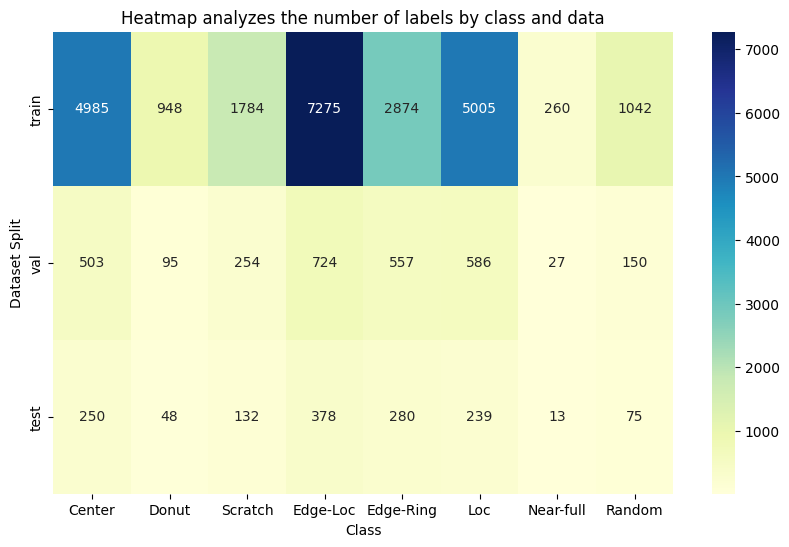

In [ ]:
import os
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Config
base_dir = '/content/drive/MyDrive/datasheet/labels'
splits = ['train', 'val', 'test']
class_names = ['Center', 'Donut', 'Scratch', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random']
num_classes = len(class_names)

#Initialize counters for each data set
label_counts = {split: Counter() for split in splits}

# Iterate through each train/val/test set
for split in splits:
    folder = os.path.join(base_dir, split)

    for root, _, files in os.walk(folder):  #  Recursively browse subdirectories
        for file in files:
            if file.endswith('.txt'):
                path = os.path.join(root, file)
                with open(path, 'r') as f:
                    for line in f:
                        if line.strip():
                            try:
                                class_id = int(float(line.strip().split()[0]))  # in case class_id is '6.0'
                                if 0 <= class_id < num_classes:
                                    label_counts[split][class_id] += 1
                            except Exception as e:
                                print(f" Error reading file {file}: {e}")

# Create DataFrame from count result
df = pd.DataFrame(columns=class_names)
for split in splits:
    row = [label_counts[split].get(i, 0) for i in range(num_classes)]
    df.loc[split] = row

# Draw heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.astype(int), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap analyzes the number of labels by class and data')
plt.xlabel('Class')
plt.ylabel('Dataset Split')
plt.show()


chạy mô hình

In [ ]:
# ============================
# Resume YOLOv8l Training
# ============================

!pip install -q ultralytics --upgrade
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')
from ultralytics import YOLO
import os

# ============================
# Paths
# ============================
project_dir = "/content/drive/MyDrive/yolo_training/wafer_yolov8l_last"
run_name = "run1"
data_yaml_path = "/content/drive/MyDrive/datasheet/data.yaml"

last_weight = os.path.join(project_dir, run_name, "weights", "last.pt")

if not os.path.exists(last_weight):
    raise FileNotFoundError("❌ last.pt not found → cannot resume")

# ============================
# Load last checkpoint
# ============================
model = YOLO(last_weight)

# ============================
# Resume training
# ============================
print("🔁 Resuming training...")
results = model.train(
    resume=True,
    data=data_yaml_path
)

print("✅ Resume complete")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔁 Resuming training...
Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/datasheet/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/My

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================
# FIX PREDICTION PATH
# ==============================
pred_labels = os.path.join(save_pred, "labels")

print("Total GT files:", len(os.listdir(gt_labels)))
print("Total Pred files:", len(os.listdir(pred_labels)))


['labels']


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from ultralytics import YOLO
from google.colab import drive

# ==============================
# 0. MOUNT DRIVE
# ==============================
drive.mount('/content/drive')

# ==============================
# 1. PATH CONFIGURATION
# ==============================
model_path = "/content/drive/MyDrive/yolo_training/wafer_yolov8l_last/run1/weights/best.pt"
test_images = "/content/drive/MyDrive/datasheet/images/test/**/*.jpg"  # QUÉT TOÀN BỘ SUBFOLDER
gt_labels = "/content/drive/MyDrive/datasheet/labels/test"
save_pred = "/content/drive/MyDrive/yolo_training/predictions"

os.makedirs(save_pred, exist_ok=True)

# ==============================
# 2. LOAD MODEL & RUN PREDICTION
# ==============================
model = YOLO(model_path)

results = model.predict(
    source=test_images,
    save_txt=True,
    save_conf=True,
    project=save_pred,
    name="labels",
    exist_ok=True,
    conf=0.25
)

# đường dẫn label dự đoán YOLOv8
pred_labels = os.path.join(save_pred/labels/*.txt)

# ==============================
# 3. HELPER FUNCTIONS
# ==============================
def yolo_to_xyxy(box):
    x_c, y_c, w, h = box
    x1 = x_c - w/2
    y1 = y_c - h/2
    x2 = x_c + w/2
    y2 = y_c + h/2
    return [x1, y1, x2, y2]

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2-x1) * max(0, y2-y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter_area

    return inter_area / union if union != 0 else 0

# ==============================
# 4. IoU CALCULATION
# ==============================
iou_per_class = defaultdict(list)

gt_files = glob.glob(os.path.join(gt_labels, "*.txt"))

for gt_path in gt_files:
    file_name = os.path.basename(gt_path)
    pred_path = os.path.join(pred_labels, file_name)

    if not os.path.exists(pred_path):
        continue

    # Read GT boxes
    gt_boxes = []
    with open(gt_path) as f:
        for line in f:
            cls, x, y, w, h = map(float, line.split())
            gt_boxes.append((int(cls), yolo_to_xyxy([x, y, w, h])))

    # Read predicted boxes
    pred_boxes = []
    with open(pred_path) as f:
        for line in f:
            cls, x, y, w, h, conf = map(float, line.split())
            pred_boxes.append((int(cls), yolo_to_xyxy([x, y, w, h])))

    # Match each GT with best IoU prediction cùng class
    for gt_cls, gt_box in gt_boxes:
        best_iou = 0
        for pred_cls, pred_box in pred_boxes:
            if pred_cls != gt_cls:
                continue
            iou = compute_iou(gt_box, pred_box)
            best_iou = max(best_iou, iou)

        iou_per_class[gt_cls].append(best_iou)

# ==============================
# 5. CLASS NAMES
# ==============================
class_names = [
    "Center", "Donut", "Scratch", "Edge-Loc",
    "Edge-Ring", "Loc", "Near-full", "Random"
]

# ==============================
# 6. HISTOGRAM IoU PER CLASS
# ==============================
for cls_id, ious in iou_per_class.items():
    plt.figure()
    plt.hist(ious, bins=20)
    plt.title(f"IoU Distribution - {class_names[cls_id]}")
    plt.xlabel("IoU")
    plt.ylabel("Frequency")
    plt.show()

# ==============================
# 7. MEAN IoU TABLE
# ==============================
print("\n===== IoU STATISTICS PER CLASS =====")
print(f"{'Class':<10} | {'Mean IoU':<10} | {'Std IoU':<10}")
print("-"*36)

for cls_id in range(len(class_names)):
    ious = iou_per_class[cls_id]
    if len(ious) == 0:
        mean_iou, std_iou = 0, 0
    else:
        mean_iou = np.mean(ious)
        std_iou = np.std(ious)

    print(f"{class_names[cls_id]:<10} | {mean_iou:.3f}     | {std_iou:.3f}")

# ==============================
# 8. GLOBAL LOCALIZATION METRIC
# ==============================
all_ious = [iou for cls in iou_per_class.values() for iou in cls]

print("\n===== OVERALL LOCALIZATION PERFORMANCE =====")
print(f"Mean IoU (All classes): {np.mean(all_ious):.3f}")
print(f"Std IoU (All classes): {np.std(all_ious):.3f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1070 /content/drive/MyDrive/datasheet/images/test/Center/wafer_106681_jpg.rf.831fd8c63941baec3142c128a59ee279.jpg: 640x640 1 Center, 62.7ms
image 2/1070 /content/drive/MyDrive/datasheet/images/test/Center/wafer_117681_jpg.rf.7a87f23580e72116dd3623785a7ebc09.jpg: 640x640 1 Center, 62.7ms
image 3/1070 /content/drive/MyDri

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


vẽ chart

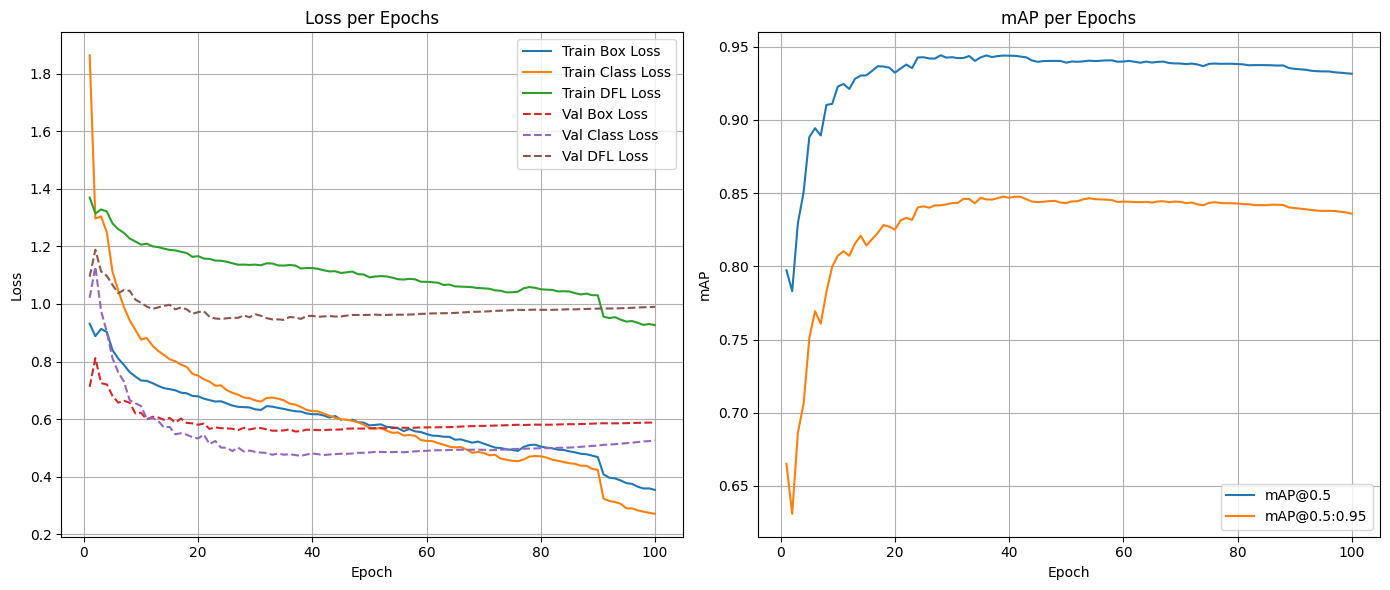

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data from CSV file vẽ chart
csv_path = '/content/drive/MyDrive/yolo_training/wafer_yolov8l_last/run1/results.csv'
df = pd.read_csv(csv_path)

# Check 'epoch' column if not present
if 'epoch' not in df.columns:
    df['epoch'] = range(len(df))

# Draw a chart
plt.figure(figsize=(14, 6))

# Loss Chart
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', linestyle='--')
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', linestyle='--')
plt.plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss', linestyle='--')
plt.title('Loss per Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# mAP chart
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
plt.title('mAP per Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# =========================================
# YOLOv8 Thesis Metadata Extraction Script
# =========================================

from ultralytics import YOLO
import torch
import platform
import psutil
import datetime
import ultralytics
import torchvision
import os

# =========================
# CONFIG
# =========================
WEIGHTS_PATH = "/content/drive/MyDrive/yolo_training/wafer_yolov8l_last/run1/weights/last.pt"

# =========================
# LOAD MODEL
# =========================
model = YOLO(WEIGHTS_PATH)
args = model.trainer.args if hasattr(model, "trainer") and model.trainer else None

# =========================
# A. TRAINING ENVIRONMENT
# =========================
print("\n================ Training Environment ================\n")

timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f"timestamp\t{timestamp}")
print(f"operating_system\t{platform.system()}")
print(f"os_version\t{platform.platform()}")
print(f"python_version\t{platform.python_version()}")

cuda_available = torch.cuda.is_available()
print(f"cuda_available\t{cuda_available}")

if cuda_available:
    print(f"cuda_version\t{torch.version.cuda}")
    print(f"cudnn_version\t{torch.backends.cudnn.version()}")
    gpu_names = [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]
    gpu_vram = [torch.cuda.get_device_properties(i).total_memory / 1024**2 for i in range(torch.cuda.device_count())]
    print(f"hardware\tgpu_model: {gpu_names}")
    print(f"gpu_vram_MB\t{gpu_vram}")
    print(f"num_gpus\t{torch.cuda.device_count()}")

print(f"cpu\t{platform.machine()}")
print(f"ram_GB\t{round(psutil.virtual_memory().total / 1024**3, 2)}")

print(f"pytorch_version\t{torch.__version__}")
print(f"torchvision_version\t{torchvision.__version__}")
print(f"ultralytics_yolov8_version\t{ultralytics.__version__}")

print(f"\nModel used: {WEIGHTS_PATH}")

# =========================
# B. TRAINING HYPERPARAMETERS
# =========================
print("\n================ Training Hyperparameters ================\n")

if args:
    print(f"batch_size\t{args.batch}")
    print(f"epochs\t{args.epochs}")
    print(f"image_size\t{args.imgsz}")
    print(f"optimizer_details\toptimizer: {args.optimizer}")
    print(f"initial_learning_rate\t{args.lr0}")
    print(f"momentum\t{args.momentum}")
    print(f"betas\t{args.betas}")
    print(f"final_lr_ratio_lrf\t{args.lrf}")
    print(f"warmup_epochs\t{args.warmup_epochs}")
    print(f"regularization\tweight_decay: {args.weight_decay}")

print("\nloss_functions")
print("classification_loss\tBCEWithLogitsLoss")
print("bounding_box_loss\tCIoU Loss")
print("distribution_focal_loss\tDFL (Distribution Focal Loss)")

# =========================
# C. MODEL INFORMATION
# =========================
print("\n================ Model Information ================\n")

print(f"yolov8_variant\t{WEIGHTS_PATH}")
print(f"pretrained_weights\tTrue")
print(f"num_classes_nc\t{model.model.nc}")
print(f"class_names\t{', '.join(model.model.names.values())}")

# =========================
# D. DATA AUGMENTATION
# =========================
print("\n================ Data Augmentation ================\n")

if args:
    aug_params = [
        "mosaic", "mixup", "copy_paste", "hsv_h", "hsv_s", "hsv_v",
        "degrees", "translate", "scale", "shear",
        "perspective", "flipud", "fliplr"
    ]
    for p in aug_params:
        print(f"{p}\t{getattr(args, p, 'N/A')}")

# =========================
# E. MODEL SELECTION & EVALUATION
# =========================
print("\n================ Model Selection And Evaluation ================\n")

print("best_model_selection_criterion\tHighest validation mAP@0.5:0.95")
print("confidence_threshold\tNone")
print("nms_iou_threshold\t0.7")
print("test_time_augmentation\tFalse")
print("multi_scale_testing\tFalse")
print("evaluation_image_size\t640")

# =========================
# F. OPTIMIZATION DETAILS
# =========================
print("\n================ Optimization Details ================\n")

if args:
    print(f"optimizer\t{args.optimizer}")
    print(f"learning_rate\t{args.lr0}")
    print(f"momentum\t{args.momentum}")
    print(f"betas\t{args.betas}")
    print(f"weight_decay\t{args.weight_decay}")

print(
    "optimizer_auto_note\t"
    "When optimizer is set to 'auto', YOLOv8 internally selects AdamW "
    "for small batch sizes and SGD for larger batches."
)

print("\n================ DONE ================\n")



================ Training Environment ================

timestamp	2026-02-05 02:18:38
operating_system	Linux
os_version	Linux-6.6.105+-x86_64-with-glibc2.35
python_version	3.12.12
cuda_available	True
cuda_version	12.6
cudnn_version	91002
hardware	gpu_model: ['Tesla T4']
gpu_vram_MB	[15095.0625]
num_gpus	1
cpu	x86_64
ram_GB	50.99
pytorch_version	2.9.0+cu126
torchvision_version	0.24.0+cu126
ultralytics_yolov8_version	8.4.11

Model used: /content/drive/MyDrive/yolo_training/wafer_yolov8l_last/run1/weights/last.pt

================ Training Hyperparameters ================


loss_functions
classification_loss	BCEWithLogitsLoss
bounding_box_loss	CIoU Loss
distribution_focal_loss	DFL (Distribution Focal Loss)

================ Model Information ================

yolov8_variant	/content/drive/MyDrive/yolo_training/wafer_yolov8l_last/run1/weights/last.pt
pretrained_weights	True
num_classes_nc	8
class_names	Center, Donut, Scratch, Edge-Loc, Edge-Ring, Loc, Near-full, Random

================ D

biểu đồ cột các lớp

IN kiến trúc model

In [ ]:
from ultralytics import YOLO

# Đường dẫn tới model đã train
model_path = "/content/drive/MyDrive/yolo_training/wafer_yolov8l_last/run1/weights/last.pt"

model = YOLO(model_path)

# In kiến trúc model
print(model.model)


chạy tệp test

In [ ]:
from ultralytics import YOLO

model = YOLO(
    '/content/drive/MyDrive/yolo_training/wafer_yolov8l_last/run1/weights/best.pt'
)

results = model.val(
    data='/content/drive/MyDrive/datasheet/data.yaml',
    split='test',          # ✅ BẮT BUỘC: test set

    imgsz=640,             # nên cố định cho reproducibility
    conf=0.001,            # YOLOv8 mặc định khi eval
    iou=0.7,               # giống setup bạn đã dùng

    save=True,             # lưu ảnh bbox
    save_txt=True,         # lưu prediction txt
    plots=True,            # confusion matrix, PR, P, R

    project='/content/drive/MyDrive/yolo_training',
    name='imagelast',      # thư mục kết quả test

    exist_ok=True,
    verbose=True
)



Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 113 layers, 43,612,776 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.0±0.0 MB/s, size: 12.6 KB)
val: Scanning /content/drive/MyDrive/datasheet/labels/test/Center... 1070 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1070/1070 6.2it/s 2:53
val: New cache created: /content/drive/MyDrive/datasheet/labels/test/Center.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 1.3it/s 51.8s
                   all       1070       1415       0.89      0.894      0.931      0.829
                Center        250        250      0.974      0.992      0.993      0.884
                 Donut         48         48      0.906      0.958      0.971      0.874
               Scratch        108        132      0.886      0.882      0.928       0.72
              Edge-Loc        225      

lấy thông số từ mô hình